In [258]:
from google.colab import drive
import pandas as pd
import numpy as np

# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/wine.csv')

In [259]:
# 컬럼 확인
print(df.columns)

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')


In [260]:
# 레이블 분포 확인
df['Wine'].value_counts()

,count
Wine,
2,71
1,59
3,48


In [261]:
# 결측치 확인
print(df.isnull().sum())

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64


In [262]:
# 결측치 제거
df = df.dropna()

In [263]:
# 입력(X), 정답(y) 분리
X = df.drop('Wine', axis=1)
y = df['Wine']

In [264]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

Y = pd.get_dummies(y).values

In [265]:
# train / test 분리
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


**손실함수**

• Binary Crossentropy

이 손실 함수는 이진 분류 문제(binary classification)에 사용된다. 모델은 두 개의 클래스 중 하나를 예측해야 하며, 정답은 일반적으로 0 또는 1의 형태로 표현된다.
이 경우 출력층에는 시그모이드(sigmoid) 활성화 함수를 사용한다. 시그모이드는 입력값을 0과 1 사이의 값으로 변환하여 특정 클래스(보통 1)에 속할 확률을 출력한다.

• Categorical Crossentropy

이 손실 함수는 다중 클래스 분류 문제(multi-class classification)에 사용된다. 모델은 세 개 이상의 클래스 중 하나를 선택해야 하며, 정답은 일반적으로 원-핫 인코딩(one-hot encoding) 형태로 표현된다. 출력층에는 소프트맥스(softmax) 활성화 함수를 사용하며, 이 함수는 각 클래스에 대한 확률 분포를 생성하고 전체 합이 1이 되도록 정규화한다.

In [266]:
# 모델
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")   # 클래스 수 맞춤
])


# 컴파일
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # one-hot이면 categorical_crossentropy
    metrics=["accuracy"])

# 모델 구조 확인
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [267]:
# 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.2920 - loss: 1.1915 - val_accuracy: 0.4483 - val_loss: 1.0483
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6018 - loss: 0.9962 - val_accuracy: 0.6207 - val_loss: 0.8965
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7345 - loss: 0.8452 - val_accuracy: 0.8621 - val_loss: 0.7672
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7699 - loss: 0.7521 - val_accuracy: 0.8621 - val_loss: 0.6567
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8319 - loss: 0.6518 - val_accuracy: 0.8966 - val_loss: 0.5628
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8850 - loss: 0.5664 - val_accuracy: 0.9655 - val_loss: 0.4736
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9115 - loss: 0.4637 - val_accuracy: 0.9655 - val_loss: 0.3938
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9469 - loss: 0.4001 - val_accuracy: 0.9655 - val_loss: 0.3247

In [268]:
# 예측
y_pred = model.predict(X_test)

# 클래스 변환
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


**loss 그래프**

모델의 예측값과 실제값 사이의 오차를 나타내는 지표

 학습 과정에서 모델이 얼마나 잘못 예측하고 있는지를 수치적으로 보여주며, 값이 낮을수록 모델의 성능이 좋은 상태

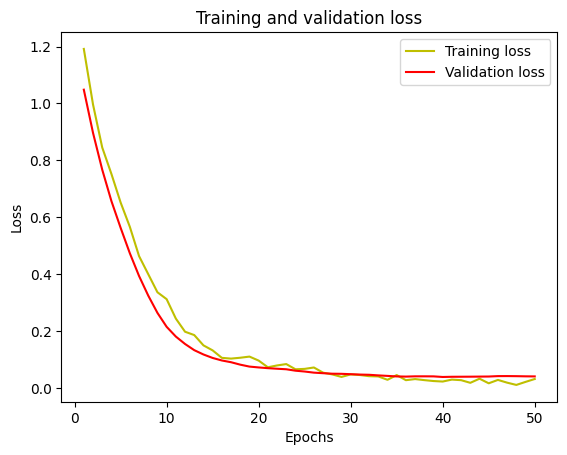

In [269]:
# loss 그래프
import matplotlib.pyplot as plt
import seaborn as sns
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**accuracy 그래프**

학습 과정에서 모델이 데이터를 얼마나 정확하게 분류하는지를 나타내는 지표

epoch에 따라 학습 데이터의 정확도와 검증 데이터의 정확도 변화를 확인할 수 있는 값


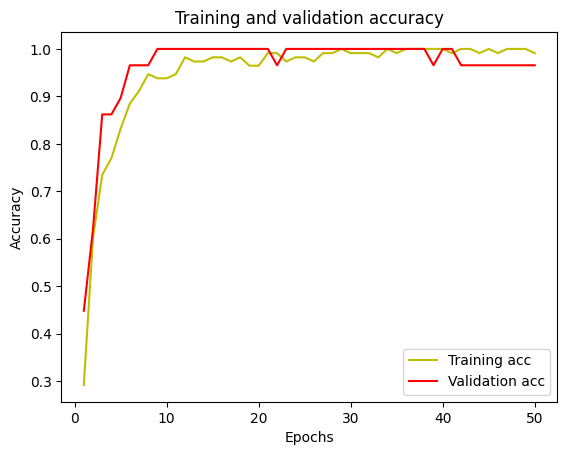

In [270]:
# accuracy 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**모델 평가**

**classification_report:**

실제값(y_test)과 예측값(y_pred_class)을 비교하여
정밀도(precision), 재현율(recall), F1-score를 계산
모델이 각 클래스를 얼마나 정확하게 분류하는지 수치적으로 확인

**confusion_matrix:**

실제 클래스와 예측 클래스를 행렬 형태로 출력
행: 실제값, 열: 예측값
어떤 클래스를 맞췄는지 / 어디서 틀렸는지 직관적으로 분석 가능

In [271]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.86      1.00      0.92         6

    accuracy                           0.97        36
   macro avg       0.95      0.98      0.96        36
weighted avg       0.98      0.97      0.97        36

[[14  0  0]
 [ 0 15  1]
 [ 0  0  6]]
